In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
print("Libraries loaded ✅")

Libraries loaded ✅


In [12]:
# loading all csv files one by one

orders = pd.read_csv('blinkit_orders.csv')
customers = pd.read_csv('blinkit_customers.csv')
order_items = pd.read_csv('blinkit_order_items.csv')
products = pd.read_csv('blinkit_products.csv')
delivery = pd.read_csv('blinkit_delivery_performance.csv')
feedback = pd.read_csv('blinkit_customer_feedback.csv')
marketing = pd.read_csv('blinkit_marketing_performance.csv')
inventory = pd.read_csv('blinkit_inventory.csv')

print("all files loaded")

all files loaded


In [13]:
# lets see whats inside each file first

print("orders shape:", orders.shape)
print(orders.head(3))

orders shape: (5000, 10)
     order_id  customer_id           order_date promised_delivery_time  \
0  1961864118     30065862  2024-07-17 08:34:01    2024-07-17 08:52:01   
1  1549769649      9573071  2024-05-28 13:14:29    2024-05-28 13:25:29   
2  9185164487     45477575  2024-09-23 13:07:12    2024-09-23 13:25:12   

  actual_delivery_time delivery_status  order_total payment_method  \
0  2024-07-17 08:47:01         On Time      3197.07           Cash   
1  2024-05-28 13:27:29         On Time       976.55           Cash   
2  2024-09-23 13:29:12         On Time       839.05            UPI   

   delivery_partner_id  store_id  
0                63230      4771  
1                14983      7534  
2                39859      9886  


In [14]:
for name, df in [("Orders", orders), ("Customers", customers),
                  ("Order Items", order_items), ("Products", products),
                  ("Delivery", delivery), ("Feedback", feedback),
                  ("Marketing", marketing), ("Inventory", inventory)]:
    print(f"--- {name} ---")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print()

--- Orders ---
Rows: 5000 | Columns: 10
Missing values: 0

--- Customers ---
Rows: 2500 | Columns: 11
Missing values: 0

--- Order Items ---
Rows: 5000 | Columns: 4
Missing values: 0

--- Products ---
Rows: 268 | Columns: 10
Missing values: 0

--- Delivery ---
Rows: 5000 | Columns: 8
Missing values: 1902

--- Feedback ---
Rows: 5000 | Columns: 8
Missing values: 0

--- Marketing ---
Rows: 5400 | Columns: 11
Missing values: 0

--- Inventory ---
Rows: 75172 | Columns: 4
Missing values: 0



In [15]:
# checking rows, columns and missing values for each dataset

datasets = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "products": products,
    "delivery": delivery,
    "feedback": feedback,
    "marketing": marketing,
    "inventory": inventory
}

for name, df in datasets.items():
    print(f"{name} --> rows: {df.shape[0]}, cols: {df.shape[1]}, missing: {df.isnull().sum().sum()}")

orders --> rows: 5000, cols: 10, missing: 0
customers --> rows: 2500, cols: 11, missing: 0
order_items --> rows: 5000, cols: 4, missing: 0
products --> rows: 268, cols: 10, missing: 0
delivery --> rows: 5000, cols: 8, missing: 1902
feedback --> rows: 5000, cols: 8, missing: 0
marketing --> rows: 5400, cols: 11, missing: 0
inventory --> rows: 75172, cols: 4, missing: 0


In [16]:
# delivery has 1902 missing values in reasons_if_delayed column
# makes sense because most orders are on time so no reason is recorded
# filling with "No Delay"

print("before:", delivery['reasons_if_delayed'].isnull().sum())
delivery['reasons_if_delayed'] = delivery['reasons_if_delayed'].fillna('No Delay')
print("after:", delivery['reasons_if_delayed'].isnull().sum())

before: 1902
after: 0


In [17]:
# converting date columns to proper datetime format
# had to check the inventory date format separately - it was different (dayfirst)

orders['order_date'] = pd.to_datetime(orders['order_date'])
feedback['feedback_date'] = pd.to_datetime(feedback['feedback_date'])
marketing['date'] = pd.to_datetime(marketing['date'])
inventory['date'] = pd.to_datetime(inventory['date'], dayfirst=True)

# extracting useful columns from order_date
orders['month'] = orders['order_date'].dt.month_name()
orders['month_num'] = orders['order_date'].dt.month
orders['year'] = orders['order_date'].dt.year
orders['day_of_week'] = orders['order_date'].dt.day_name()

print("dates fixed")
print(orders[['order_date','month','year','day_of_week']].head(3))

dates fixed
           order_date      month  year day_of_week
0 2024-07-17 08:34:01       July  2024   Wednesday
1 2024-05-28 13:14:29        May  2024     Tuesday
2 2024-09-23 13:07:12  September  2024      Monday


total revenue: Rs.11,009,308.50
total orders: 5000
average order value: Rs.2,201.86


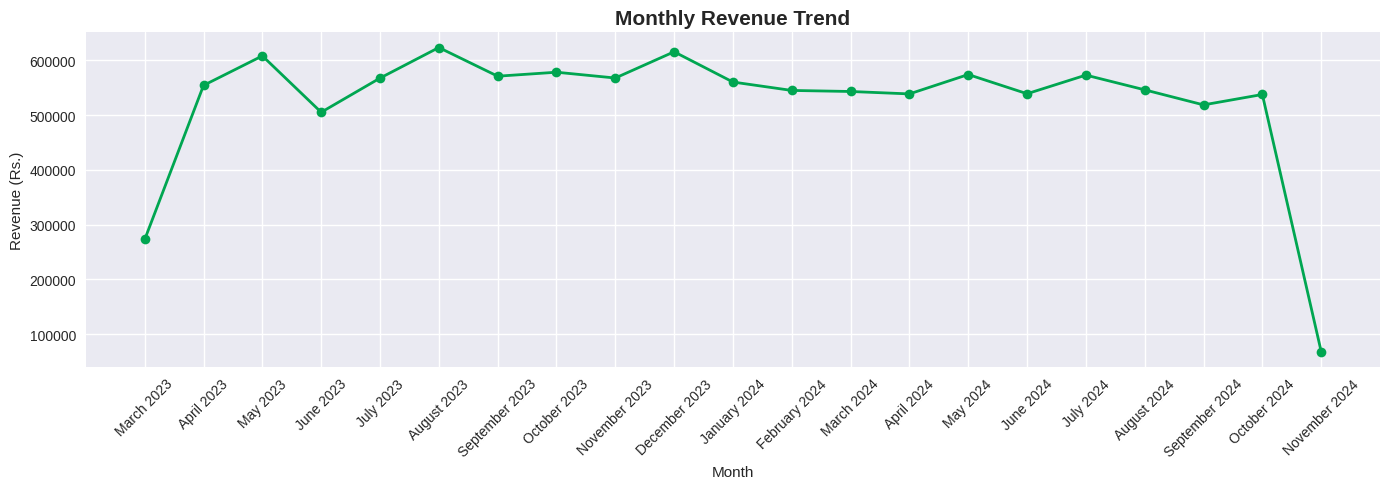

In [18]:
# calculating the key numbers first before going into charts

total_revenue = orders['order_total'].sum()
total_orders = orders['order_id'].nunique()
avg_order = orders['order_total'].mean()

print(f"total revenue: Rs.{total_revenue:,.2f}")
print(f"total orders: {total_orders}")
print(f"average order value: Rs.{avg_order:,.2f}")

# grouping by month to see revenue trend over time

monthly = orders.groupby(['year','month_num','month'])['order_total'].sum().reset_index()
monthly = monthly.sort_values(['year','month_num'])
monthly['label'] = monthly['month'] + ' ' + monthly['year'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly['label'], monthly['order_total'], marker='o', color='#00a651', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

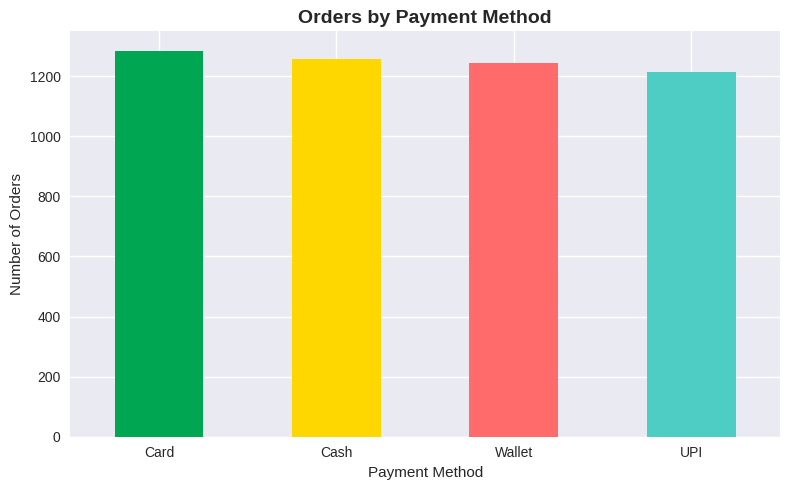

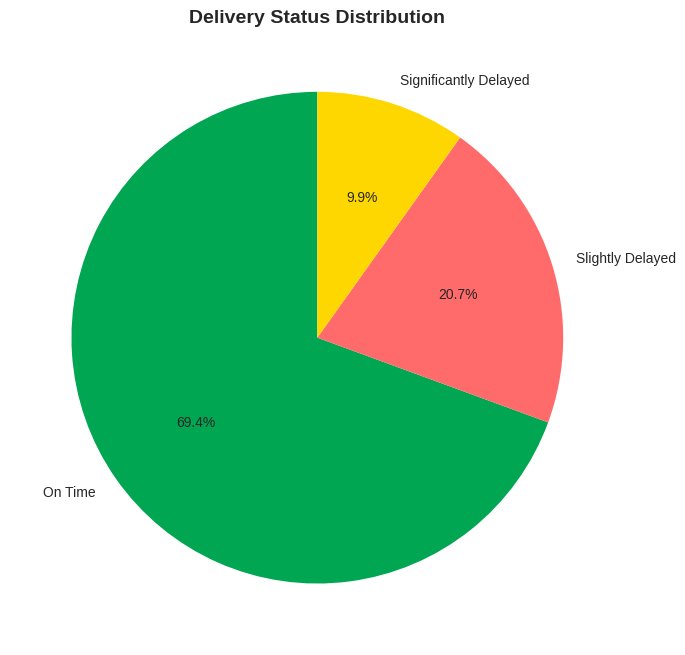

Payment & delivery charts saved ✅


In [19]:
# Payment Method Distribution
payment = orders['payment_method'].value_counts()

plt.figure(figsize=(8,5))
payment.plot(kind='bar', color=['#00a651','#ffd700','#ff6b6b','#4ecdc4'])
plt.title('Orders by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('payment_methods.png', dpi=150)
plt.show()

# Delivery Status
delivery_status = orders['delivery_status'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(delivery_status, labels=delivery_status.index, autopct='%1.1f%%',
        colors=['#00a651','#ff6b6b','#ffd700'], startangle=90)
plt.title('Delivery Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_status.png', dpi=150)
plt.show()
print("Payment & delivery charts saved ✅")

/tmp/ipykernel_1566/1257440324.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1566/1257440324.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('top_categories.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


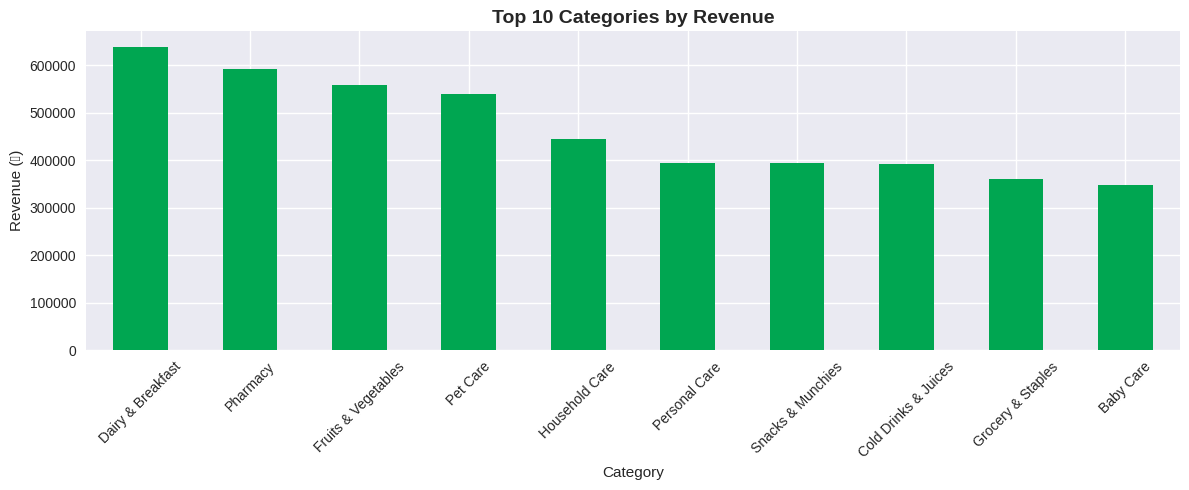

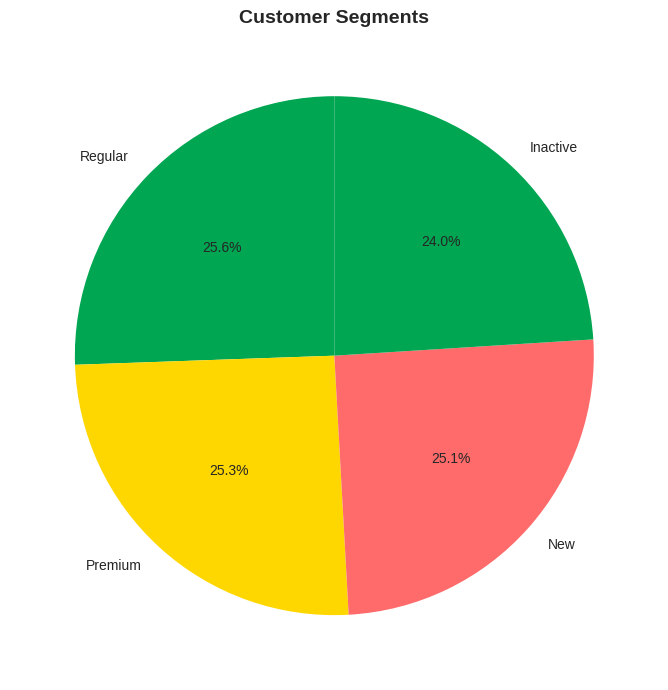

Category & segment charts saved ✅


In [20]:
# Merge orders with order_items and products
merged = order_items.merge(products[['product_id','category','brand']], on='product_id')
merged['revenue'] = merged['quantity'] * merged['unit_price']

# Top categories by revenue
top_categories = merged.groupby('category')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_categories.plot(kind='bar', color='#00a651')
plt.title('Top 10 Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()

# Customer Segments
seg = customers['customer_segment'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(seg, labels=seg.index, autopct='%1.1f%%',
        colors=['#00a651','#ffd700','#ff6b6b'], startangle=90)
plt.title('Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()
print("Category & segment charts saved ✅")

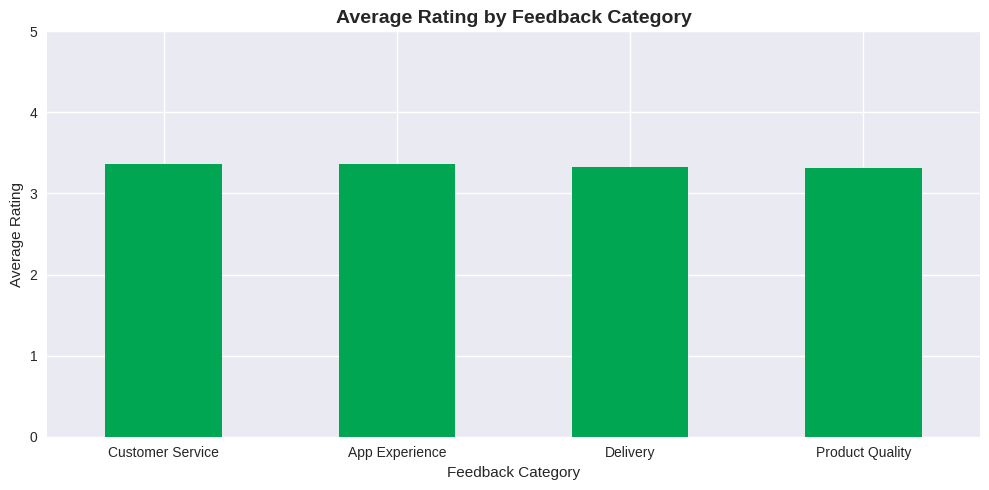

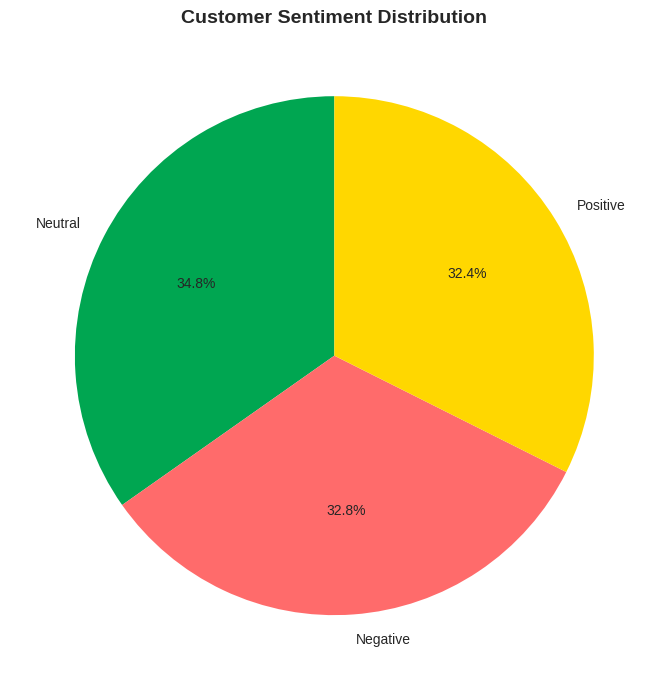

Feedback charts saved ✅


In [21]:
# Average rating by feedback category
avg_rating = feedback.groupby('feedback_category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_rating.plot(kind='bar', color='#00a651')
plt.title('Average Rating by Feedback Category', fontsize=14, fontweight='bold')
plt.xlabel('Feedback Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('avg_rating_category.png', dpi=150)
plt.show()

# Sentiment Distribution
sentiment = feedback['sentiment'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(sentiment, labels=sentiment.index, autopct='%1.1f%%',
        colors=['#00a651','#ff6b6b','#ffd700'], startangle=90)
plt.title('Customer Sentiment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment.png', dpi=150)
plt.show()
print("Feedback charts saved ✅")

/tmp/ipykernel_1566/3602846138.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1566/3602846138.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('marketing_channel.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


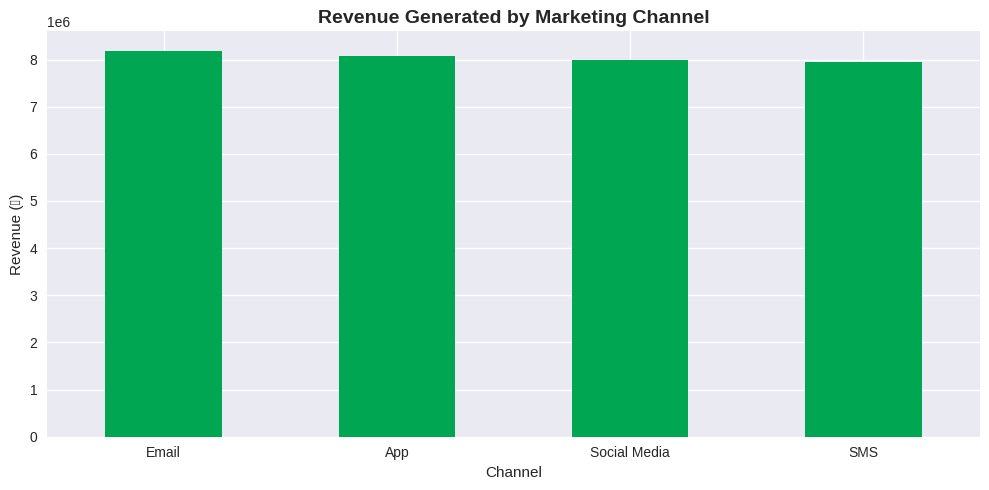

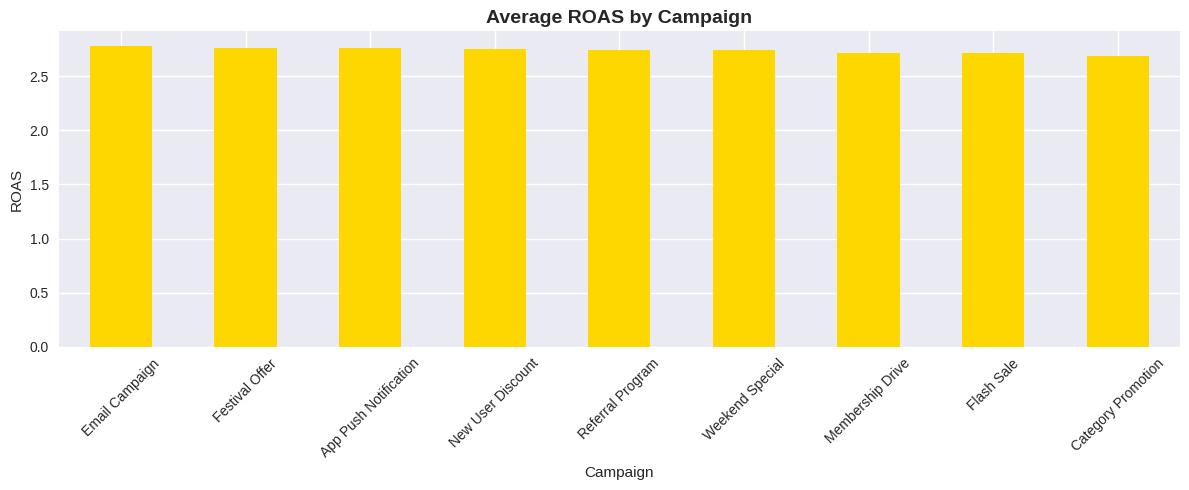

Marketing charts saved ✅


In [22]:
# Revenue generated by channel
channel_revenue = marketing.groupby('channel')['revenue_generated'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
channel_revenue.plot(kind='bar', color='#00a651')
plt.title('Revenue Generated by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('marketing_channel.png', dpi=150)
plt.show()

# Average ROAS by campaign
roas = marketing.groupby('campaign_name')['roas'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,5))
roas.plot(kind='bar', color='#ffd700')
plt.title('Average ROAS by Campaign', fontsize=14, fontweight='bold')
plt.xlabel('Campaign')
plt.ylabel('ROAS')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('roas_campaign.png', dpi=150)
plt.show()
print("Marketing charts saved ✅")

In [23]:
# Merge master sales table
sales_master = orders.merge(customers[['customer_id','customer_segment','area']], on='customer_id', how='left')
sales_master = sales_master.merge(order_items, on='order_id', how='left')
sales_master = sales_master.merge(products[['product_id','product_name','category','brand','margin_percentage']], on='product_id', how='left')
sales_master['revenue'] = sales_master['quantity'] * sales_master['unit_price']

# Export all clean files
sales_master.to_csv('blinkit_sales_master.csv', index=False)
feedback.to_csv('blinkit_feedback_clean.csv', index=False)
marketing.to_csv('blinkit_marketing_clean.csv', index=False)
delivery.to_csv('blinkit_delivery_clean.csv', index=False)

print("✅ All clean files exported!")
print(f"Sales Master shape: {sales_master.shape}")
print(f"Columns: {list(sales_master.columns)}")

✅ All clean files exported!
Sales Master shape: (5000, 24)
Columns: ['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id', 'month', 'month_num', 'year', 'day_of_week', 'customer_segment', 'area', 'product_id', 'quantity', 'unit_price', 'product_name', 'category', 'brand', 'margin_percentage', 'revenue']


In [24]:
from google.colab import files

files.download('blinkit_sales_master.csv')
files.download('blinkit_feedback_clean.csv')
files.download('blinkit_marketing_clean.csv')
files.download('blinkit_delivery_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

top5 = merged.groupby('category')['revenue'].sum().sort_values(ascending=False).head(5).reset_index()
top5.to_csv('blinkit_top5_categories.csv', index=False)
print(top5)
files.download('blinkit_top5_categories.csv')

              category    revenue
0    Dairy & Breakfast  639222.19
1             Pharmacy  592368.57
2  Fruits & Vegetables  559053.08
3             Pet Care  539888.75
4       Household Care  444244.25


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Create properly sorted monthly revenue
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month_num'] = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.strftime('%b %Y')  # e.g. "Mar 2023"

monthly_revenue = orders.groupby(['month_num','month_name'])['order_total'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('month_num')

monthly_revenue.to_csv('blinkit_monthly_revenue.csv', index=False)
files.download('blinkit_monthly_revenue.csv')
print(monthly_revenue.head(10))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   month_num month_name  order_total
0          1   Jan 2024    560423.56
1          2   Feb 2024    545090.11
2          3   Mar 2023    272878.96
3          3   Mar 2024    543181.85
4          4   Apr 2023    554344.77
5          4   Apr 2024    538754.75
6          5   May 2023    608213.54
7          5   May 2024    574163.61
8          6   Jun 2023    505227.66
9          6   Jun 2024    539074.85
